# Financial Time Series ML Analysis: Ethereum vs. Novo Nordisk

## Project overview
This notebook compares **Ethereum (ETH)** and **Novo Nordisk** using descriptive analytics and machine learning.  
The objective is to assess three related questions:

1. How do the two assets compare in terms of **return and volatility**?
2. Can unsupervised methods help identify **market regimes** and **anomalous periods**?
3. Can classification models predict the **direction of future returns** over short horizons?

## Methods used
- Data cleaning and feature engineering
- Return and volatility analysis
- Gaussian Mixture Models for regime detection
- Isolation Forest for anomaly detection
- Hidden Markov Models for crash-probability features
- Decision Trees and XGBoost for return-direction prediction

## Notes
This version has been cleaned up for portfolio use:
- redundant exploratory cells were removed
- section titles were clarified
- evaluation metrics were made more explicit
- the notebook now follows a clearer analytical narrative

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from hmmlearn.hmm import GaussianHMM

## 1. Data loading and cleaning

In [8]:
# Loading dataframes

df_eth = pd.read_csv("../data/_eth_dkk.csv", header=0, sep = ";")
df_novo = pd.read_csv("../data/_XCSE_NOVO-1.csv")

In [9]:
# As we can see for novo data all data is stored as string, we should convert open, high low and close to float for later analysis of returns
# However right now these number are stored with a decimal point for thousands which we want to remove for conversion. Decimal point is also used for
# cents which we do not want to remove
# So we need to use a regex to only match the first decimal point

df_novo["Open"] = df_novo["Open"].str.replace(r"\.(?=.*\.)", "",regex=True).astype(float)       # Match a dot that is followed by another dot (?= means do not match this but look ahead for the part before to be matched)
df_novo["High"] = df_novo["High"].str.replace(r"\.(?=.*\.)", "",regex=True).astype(float)
df_novo["Low"] = df_novo["Low"].str.replace(r"\.(?=.*\.)","",regex=True).astype(float) 
df_novo["Close"] = df_novo["Close"].str.replace(r"\.(?=.*\.)","",regex=True).astype(float)
# Convert Date to date format
df_novo["Date"] = pd.to_datetime(df_novo["Date"])
df_novo.head()
df_novo.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    250 non-null    datetime64[us]
 1   Open    250 non-null    float64       
 2   High    250 non-null    float64       
 3   Low     250 non-null    float64       
 4   Close   250 non-null    float64       
 5   Volume  250 non-null    str           
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 11.8 KB


In [10]:
# For consistency convert Volume into integer
df_novo["Volume"] =df_novo["Volume"].str.replace(",", "").astype(int)
# Also we would want to reverse the order for later plotting and consistency with eth data (Dates ascending not descending)
df_novo = df_novo.iloc[::-1].reset_index(drop=True)     # reverse order and reset indices (1 to 366)

# Test
df_novo.head()


,Date,Open,High,Low,Close,Volume
0,2025-02-27,630.0,645.8,628.3,641.8,2974061
1,2025-02-28,641.0,648.2,631.2,644.5,7285161
2,2025-03-03,650.0,651.2,636.2,639.1,2242871
3,2025-03-04,634.6,642.4,616.2,616.2,3058878
4,2025-03-05,616.1,649.4,614.0,631.5,3515981


In [11]:
# Translating feature names of eth df for understandability and consistency

df_eth = df_eth.rename(columns = {"Dato": "Date", "Åbning":"Open", "Høj":"High", "Lav": "Low", "Luk": "Close", 
                         "Volumen":"Volume", "Markedsværdi": "Market Value", "Ændring, %":"Change, %"})
# Convert date column to date format
df_eth["Date"] = pd.to_datetime(df_eth["Date"])
# Display Volume as integer f or consistency
df_eth["Volume"] = df_eth["Volume"].str.replace("B", "").astype(float)*1000000000
#df_eth
df_eth.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          366 non-null    datetime64[us]
 1   Open          366 non-null    float64       
 2   High          366 non-null    float64       
 3   Low           366 non-null    float64       
 4   Close         366 non-null    float64       
 5   Volume        366 non-null    float64       
 6   Market Value  366 non-null    str           
 7   Change, %     366 non-null    float64       
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 23.0 KB


In [12]:

# Calculate returns and intra-day range
df_novo['Returns'] = df_novo['Close'].pct_change()
df_novo['Range'] = (df_novo['High'] - df_novo['Low']) / df_novo['Close']
df_novo = df_novo.dropna()

df_eth['Returns'] = df_eth['Close'].pct_change()
df_eth['Range'] = (df_eth['High'] - df_eth['Low']) / df_eth['Close']
df_eth = df_eth.dropna()

## 2. Exploratory return analysis

This section compares the two assets using closing prices and rolling return measures.  
The goal is not only to compare raw performance, but also to establish a baseline for the later ML sections.

Text(0.5, 1.0, 'Ethereum Price Development')

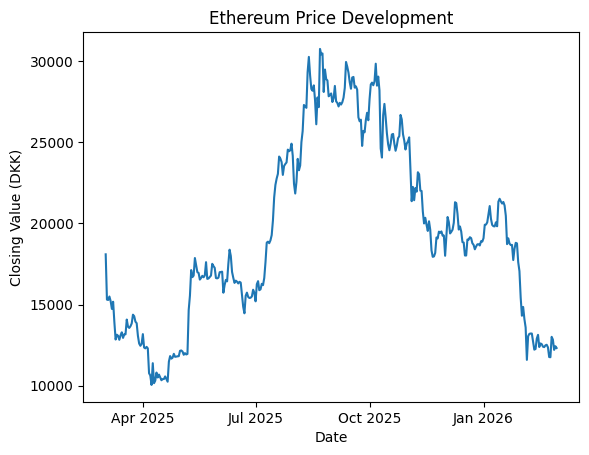

In [13]:
# Let's also plot the yearly development of the stock. We will use closing prices as a daily datapoint
import matplotlib.dates as mdates

fig, ax = plt.subplots()
ax.plot(df_eth["Date"], df_eth["Close"])
# Set x axis to show months instead of individual days
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xlabel("Date")
plt.ylabel("Closing Value (DKK)")
plt.title("Ethereum Price Development")

Text(0.5, 1.0, 'Novo Nordisk Stock Price Development')

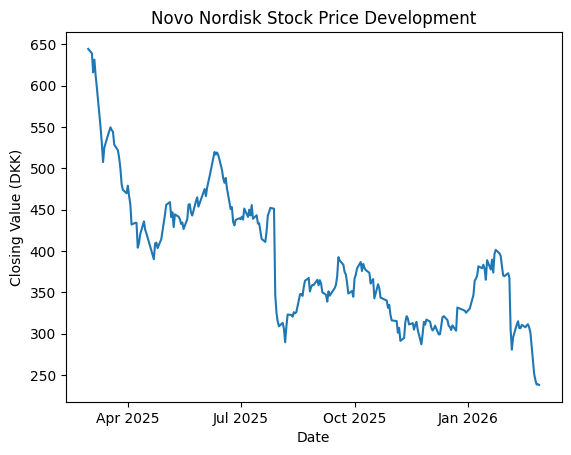

In [14]:
# Plot for Novo
fig, ax = plt.subplots()
ax.plot(df_novo["Date"], df_novo["Close"])
# Set x axis to show months instead of individual days
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xlabel("Date")
plt.ylabel("Closing Value (DKK)")
plt.title("Novo Nordisk Stock Price Development")

In [15]:
# First look at basic 1 year ROI:
N = len(df_eth["Open"])
#roi_eth = (df_eth["Close"][N-1] - df_eth["Open"][0])/ df_eth["Open"][0]
roi_eth = (df_eth["Close"].iloc[-1] - df_eth["Open"].iloc[0]) / df_eth["Open"].iloc[0]
N = len(df_novo["Open"])
#roi_novo = (df_novo["Close"][N-1] - df_novo["Open"][0])/ df_novo["Open"][0]
roi_novo = (df_novo["Close"].iloc[-1] - df_novo["Open"].iloc[0]) / df_novo["Open"].iloc[0]
print(f"1 year ROI ETH: {roi_eth:.2%}")
print(f"1 year ROI Novo: {roi_novo:.2%}")

1 year ROI ETH: -22.70%
1 year ROI Novo: -62.89%


In [16]:
# Calculating a 30 day rolling ROI
# For eth we already have daily change rate for novo we need to calculate it
df_novo["change"] = df_novo["Returns"]

df_novo["rolling30 ROI"] = (1+df_novo["change"]).rolling(30).apply(lambda x: x.prod()-1)

df_eth["rolling30 ROI"] = (1+df_eth["Change, %"]/100).rolling(30).apply(lambda x: x.prod()-1)

Text(0.5, 1.0, 'ETH 30 day rolling ROI')

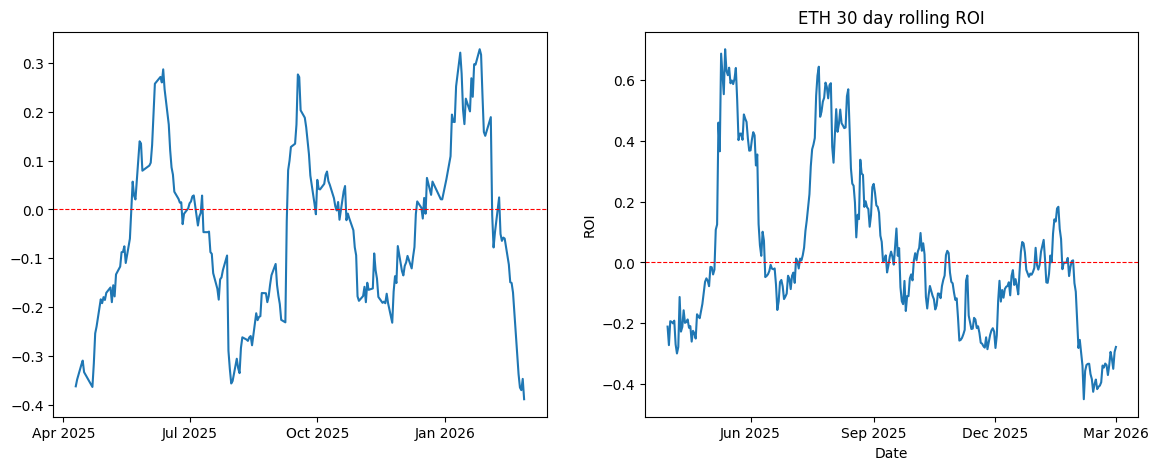

In [17]:
# Plot for Novo
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14, 5))
ax1.plot(df_novo["Date"], df_novo["rolling30 ROI"])
# Set x axis to show months instead of individual days
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Closing Value (DKK)")
plt.title("Novo Nordisk Stock 30 day rolling ROI")

# Plot for eth

ax2.plot(df_eth["Date"], df_eth["rolling30 ROI"])
# Set x axis to show months instead of individual days
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Date")
ax2.set_ylabel("ROI") 
ax2.set_title("ETH 30 day rolling ROI")



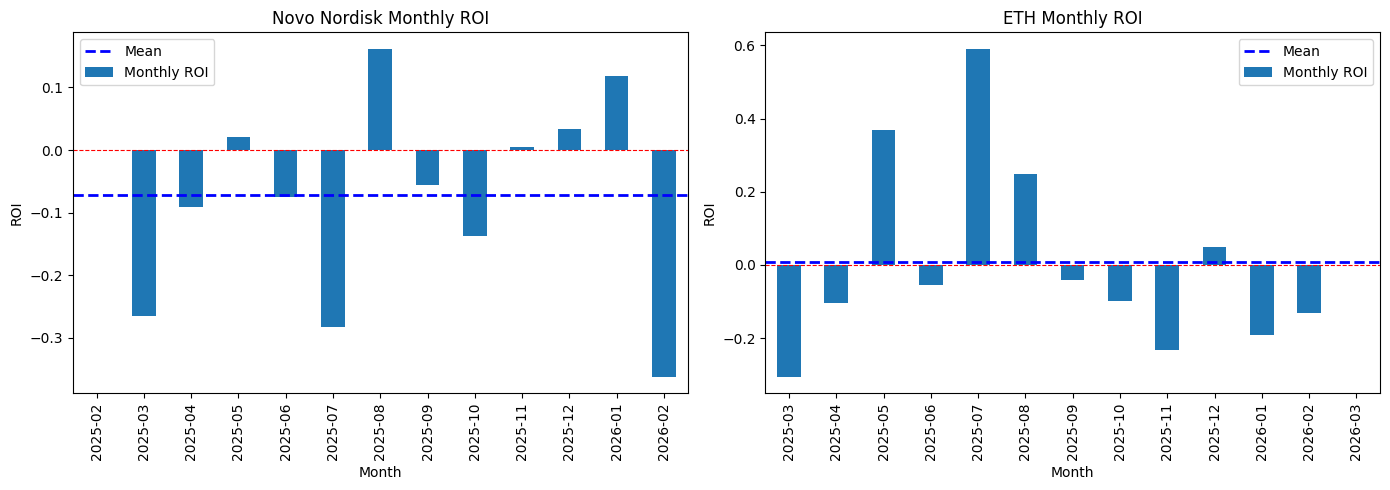

In [18]:
from matplotlib.ticker import FuncFormatter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Month on month ROI - Novo
monthly_roi_novo = df_novo.groupby(df_novo["Date"].dt.to_period("M"))["Close"].apply(
    lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0]
)
monthly_roi_novo.plot(kind="bar", ax=ax1, label="Monthly ROI")
ax1.axhline(y=monthly_roi_novo.mean(), color="blue", linewidth=2.0, linestyle="--", label="Mean")
ax1.set_title("Novo Nordisk Monthly ROI")
ax1.set_xlabel("Month")
ax1.set_ylabel("ROI")
ax1.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax1.legend()
# Month on month ROI - ETH
monthly_roi_eth = df_eth.groupby(df_eth["Date"].dt.to_period("M"))["Close"].apply(
    lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0]          # iloc[-1] accesses last close value of the month, [0] accesses first
)
monthly_roi_eth.plot(kind="bar", ax=ax2, label= "Monthly ROI")
ax2.axhline(y=monthly_roi_eth.mean(), color="blue", linewidth=2.0, linestyle="--", label="Mean")
ax2.set_title("ETH Monthly ROI")
ax2.set_xlabel("Month")
ax2.set_ylabel("ROI")
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.legend()
plt.tight_layout()
plt.show()

### Interim takeaway
Over the sample period, Ethereum delivered the stronger relative return profile, while Novo Nordisk underperformed more sharply.  
This does **not** imply ETH is the superior asset in general — only that it performed better within the selected observation window.

## 3. Volatility analysis

In [19]:
df_eth["daily_return"] = df_eth["Change, %"] / 100
df_eth["volatility_30d"] = df_eth["daily_return"].rolling(30).std()

df_novo["daily_return"] = df_novo["change"]
df_novo["volatility_30d"] = df_novo["daily_return"].rolling(30).std()


In [20]:
ret_vol_eth = df_eth["daily_return"].std()
ret_vol_novo = df_novo["daily_return"].std()

print(f"Volatility of daily returns ETH: {ret_vol_eth:.4f}")
print(f"Volatility of daily returns Novo Nordisk stock: {ret_vol_novo:.4f}")

Volatility of daily returns ETH: 0.0409
Volatility of daily returns Novo Nordisk stock: 0.0354


### Interpretation
ETH exhibits higher day-to-day variability than Novo Nordisk.  
That makes the return comparison more nuanced: higher upside potential is paired with higher uncertainty and larger price swings.

## 4. Unsupervised market diagnostics

In [21]:
from sklearn.mixture import GaussianMixture

#def market_regimes(df):
#    
#    X = df[['Returns', 'Range']]
#    gmm = GaussianMixture(n_components=2, random_state=42)
#    df['Regime'] = gmm.fit_predict(X)


def market_regimes(df, vol_col="volatility_30d", n_regimes=2):
    data = df[[vol_col]].dropna()
    scaler = StandardScaler()
    X = scaler.fit_transform(data)
    
    km = KMeans(n_clusters=n_regimes, random_state=42, n_init=10)
    clusters = km.fit_predict(X)
    
    df.loc[data.index, "regime"] = clusters
    
    # 0 = low vol, 1 = high vol
    means = df.groupby("regime")[vol_col].mean()
    low_cluster = means.idxmin()
    df["Regime"] = df["regime"].map(
        lambda c: "Low Volatility" if c == low_cluster else "High Volatility"
    )
    


In [22]:

from sklearn.ensemble import IsolationForest

def anomaly_detection(df):
    
    X = df[['Returns', 'Range']]
    iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    df['Anomaly_Score'] = iso.fit_predict(X)
    df['Is_Anomaly'] = df['Anomaly_Score'].map({1: False, -1: True})


In [23]:
import numpy as np
from hmmlearn import hmm

def crash_regime(df, window=5, n_states=3):

    df['Rolling_Range'] = df['Returns'].rolling(window=window).std()
    copy = df[['Returns', 'Rolling_Range']].dropna()
    X = copy
    model = hmm.GaussianHMM(n_components=n_states, covariance_type='full', n_iter=100, random_state=42)
    model.fit(X)
    state_means = model.means_[:, 0]
    crash_idx = np.argsort(state_means)[0]
    probs = model.predict_proba(X)
    df['Crash_Prob'] = np.nan
    df.loc[copy.index, 'Crash_Prob'] = probs[:, crash_idx]


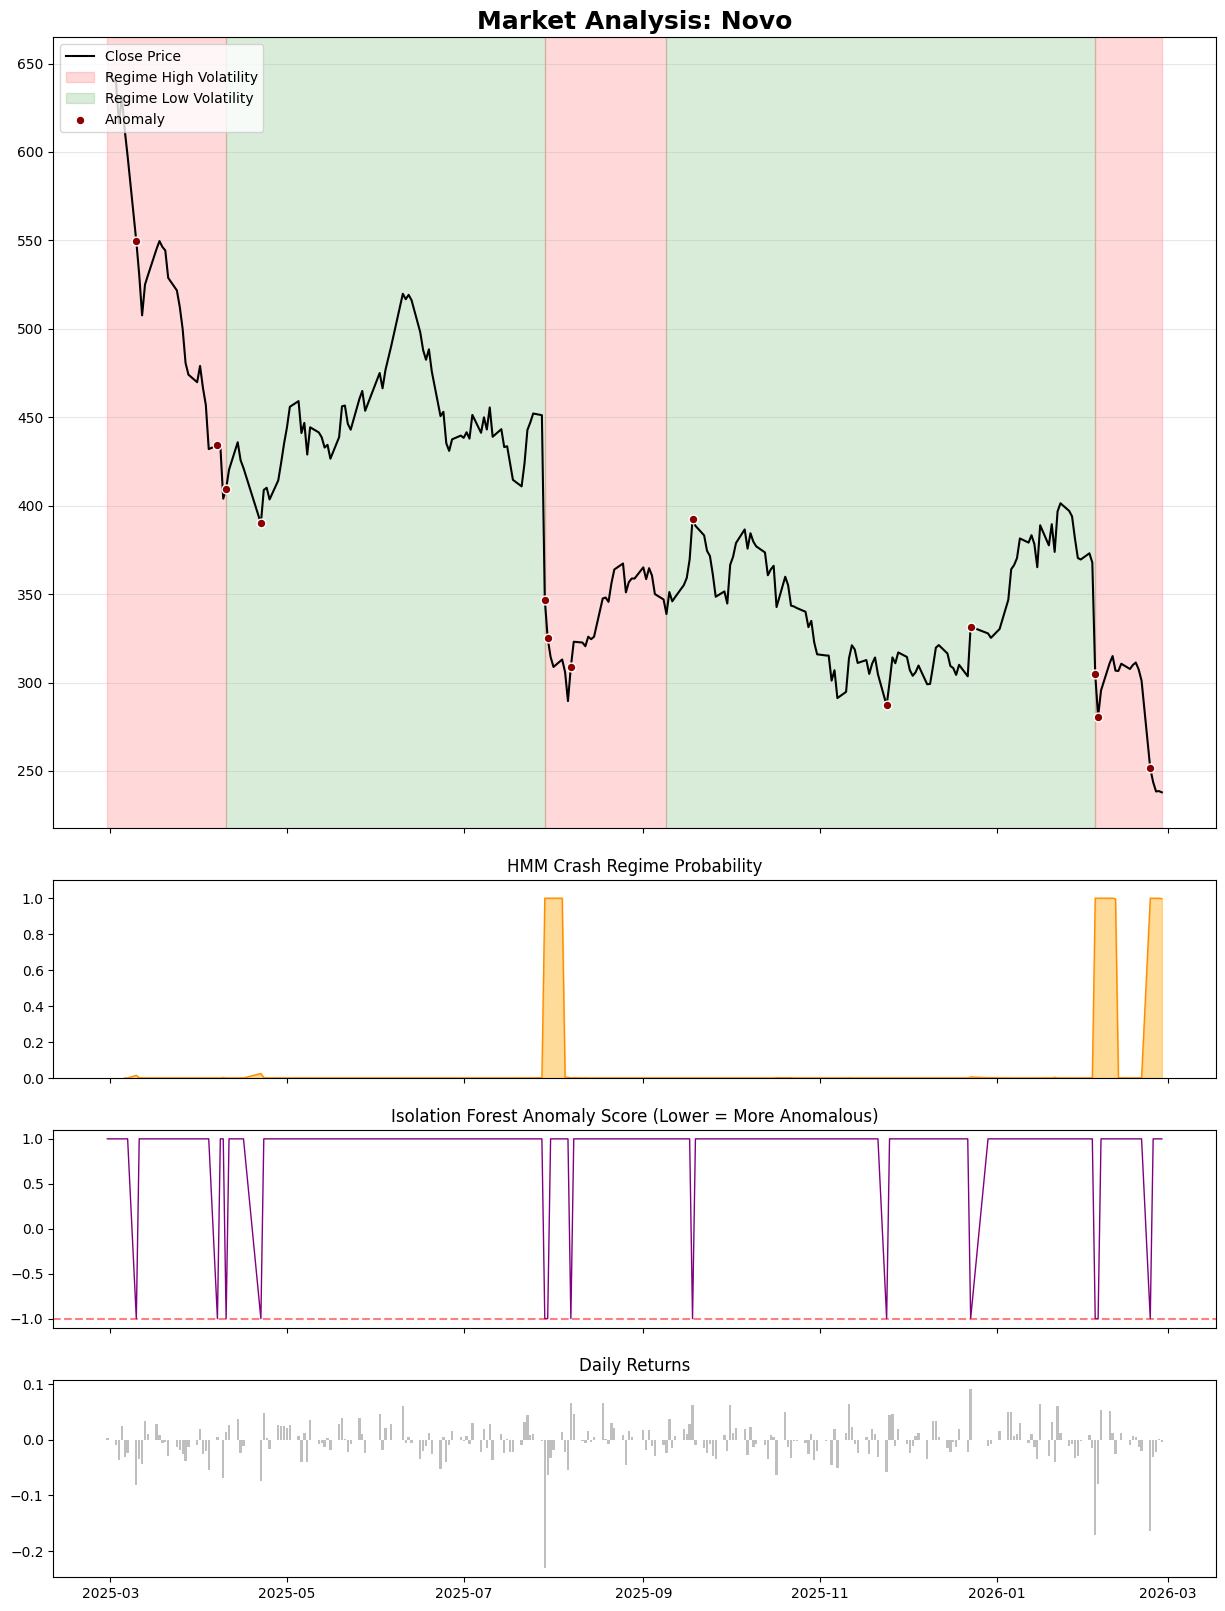

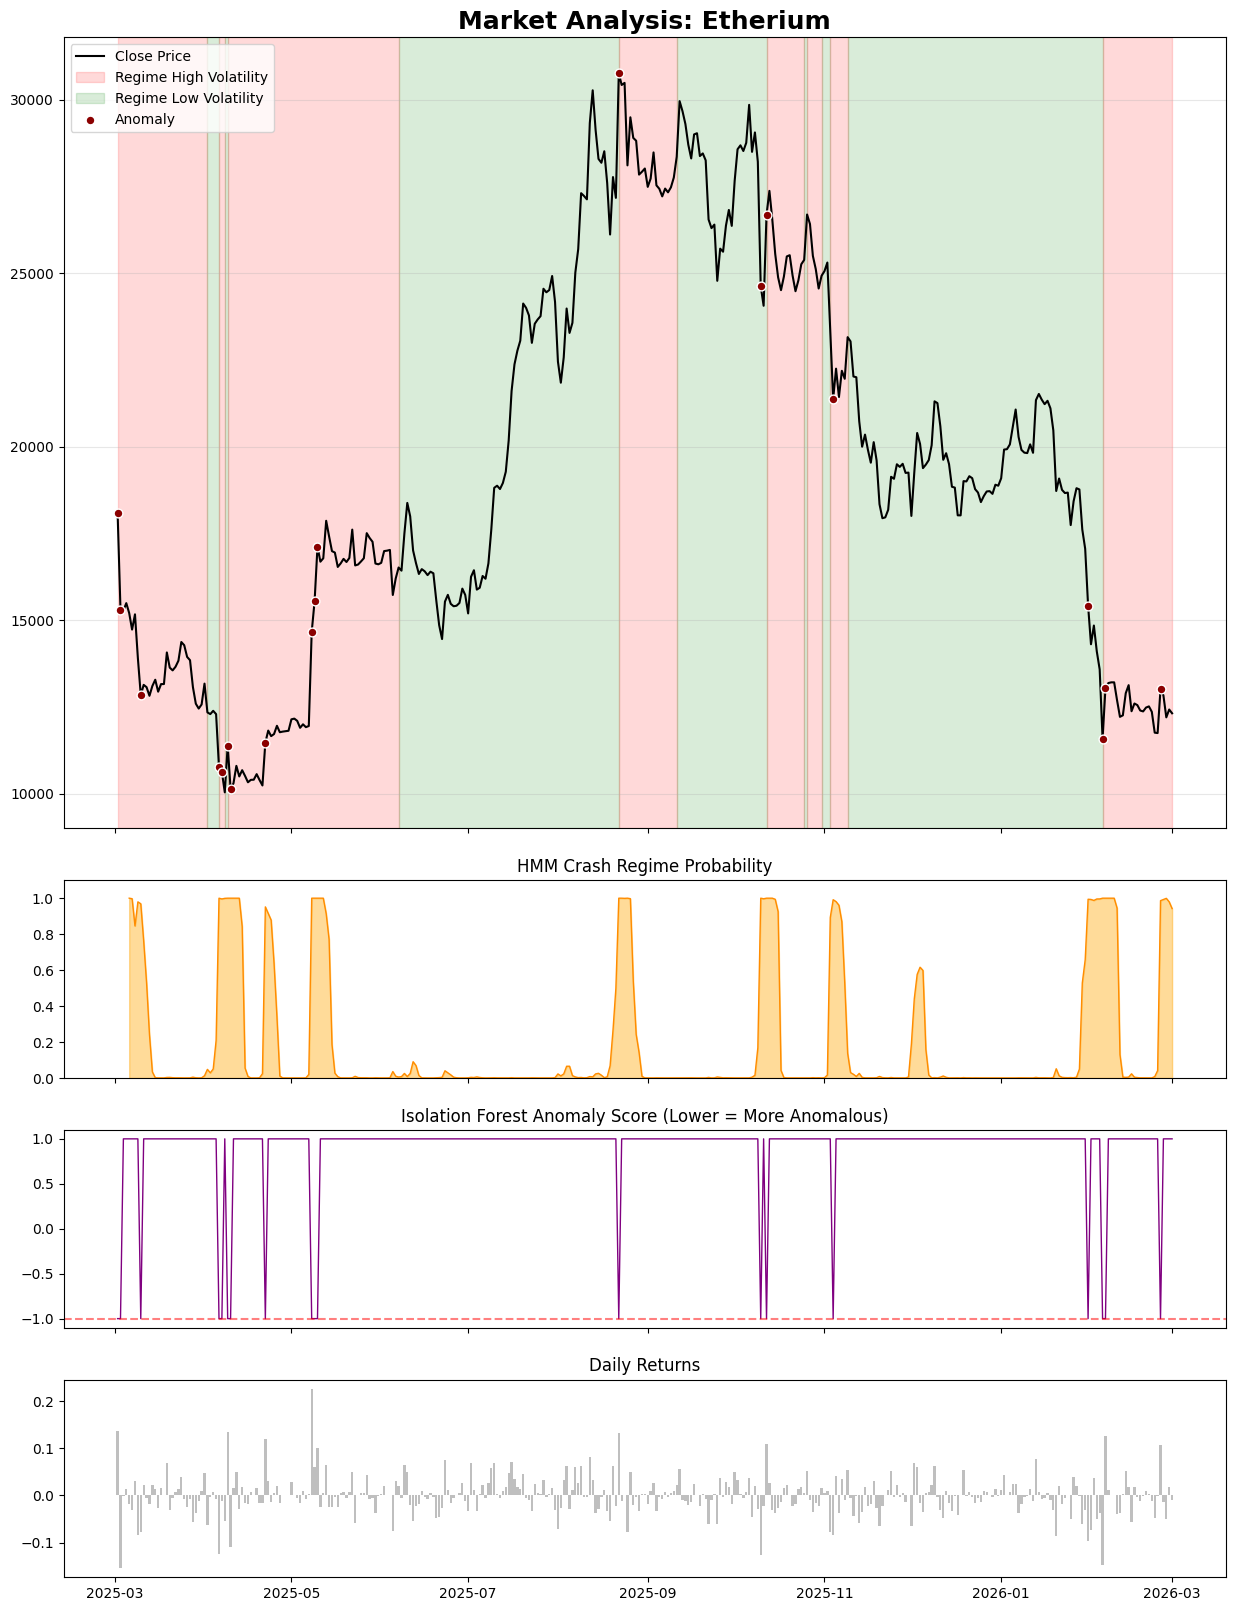

In [24]:
import matplotlib.pyplot as plt

def print_cash(df, name):
    # 1. Run Data Processing
    market_regimes(df)
    anomaly_detection(df)
    crash_regime(df)
    
    # 2. Setup Plotting
    fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=True, 
                             gridspec_kw={'height_ratios': [4, 1, 1, 1]})
    plt.subplots_adjust(hspace=0.15)
    
    # --- Panel 1: Unifying Price Chart + Market Regime Shading ---
    axes[0].plot(df['Date'], df['Close'], color='black', lw=1.5, label='Close Price', zorder=2)
    
    # Highlighting Regimes with axvspan for better visibility
    # We identify contiguous blocks of the same regime to draw spans
    df['regime_change'] = df['Regime'].ne(df['Regime'].shift())
    regime_starts = df[df['regime_change']].index.tolist()
    regime_starts.append(df.index[-1])
    
    for i in range(len(regime_starts)-1):
        start_idx = regime_starts[i]
        end_idx = regime_starts[i+1]
        regime_val = df.loc[start_idx, 'Regime']
        color = 'green' if regime_val == 'Low Volatility' else 'red'
        axes[0].axvspan(df.loc[start_idx, 'Date'], df.loc[end_idx, 'Date'], 
                        color=color, alpha=0.15, label=f'Regime {regime_val}' if i < 2 else "")

    # Overlay Anomalies
    anomalies = df[df['Is_Anomaly'] == True]
    axes[0].scatter(anomalies['Date'], anomalies['Close'], color='darkred', 
                    edgecolor='white', s=40, label='Anomaly', zorder=5)
    
    axes[0].set_title(f"Market Analysis: {name}", fontsize=18, fontweight='bold')
    axes[0].legend(loc='upper left', frameon=True)
    axes[0].grid(axis='y', alpha=0.3)

    # --- Panel 2: Returns (To visualize volatility vs regimes) ---
    axes[3].bar(df['Date'], df['Returns'], color='gray', alpha=0.5)
    axes[3].set_title("Daily Returns")

    # --- Panel 3: Anomaly Scores ---
    axes[2].plot(df['Date'], df['Anomaly_Score'], color='purple', lw=1)
    axes[2].axhline(y=-1, color='red', linestyle='--', alpha=0.5)
    axes[2].set_title("Isolation Forest Anomaly Score (Lower = More Anomalous)")

    # --- Panel 4: Crash Probabilities ---
    axes[1].fill_between(df['Date'], df['Crash_Prob'], color='orange', alpha=0.4)
    axes[1].plot(df['Date'], df['Crash_Prob'], color='darkorange', lw=1)
    axes[1].set_title("HMM Crash Regime Probability")
    axes[1].set_ylim(0, 1.1)

    plt.show()

print_cash(df_novo, 'Novo')
print_cash(df_eth, 'Etherium')

The following diagnostics are used to enrich the analysis:

- **Gaussian Mixture Models** to separate volatility regimes  
- **Isolation Forest** to identify unusual market observations  
- **Hidden Markov Models** to construct a crash-probability feature for later prediction tasks

## 5. Predicting return direction

### Feature set
The model features combine lagged returns, volatility indicators, trading-volume changes, and crash-probability estimates.
Because this is time-series data, train/test splits remain **chronological** rather than shuffled.

In [25]:
# Training set

# We choose 3 training features
# return_lag5: captures the idea that recent trends influence current development of stock price
# vol 30d: earlier analysis showed that volatility level is associated with return direction (market regime analysis)
# vol_regime: This is meaningful information about volatility seasons we captured in earlier analysis


def build_features(df):
    X = pd.DataFrame(index=df.index)
    
    X["return_lag5"]     = df["daily_return"].shift(5)
    X["vol_30d"]         = df["volatility_30d"]
    X["vol_regime"]      = (df["Regime"].shift(1) == "High Volatility").astype(int)
    X["volume_change"]   = df["Volume"].pct_change().shift(1)
    # crash regime features from HMM
    X["crash_prob"]      = df["Crash_Prob"].shift(1).fillna(0)
    
    #Additional features to improve model accuracy (irrelevant ones are later eliminated)
    X["return_lag1"]     = df["daily_return"].shift(1)
    X["return_lag10"]    = df["daily_return"].shift(10)
    X["vol_7d"]          = df["daily_return"].rolling(7).std()
    X["mean_return_30d"] = df["daily_return"].rolling(30).mean()
    

    return X

X_eth  = build_features(df_eth)
X_novo = build_features(df_novo)


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

def evaluate_predictions(y_true, y_pred, name):
    """Print standard classification metrics and display a confusion matrix."""
    print(f"\n{name} — evaluation summary")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}")
    print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.3f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"]).plot()
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

### 5.1 Decision Tree baseline

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from collections import Counter
from sklearn.feature_selection import SelectFromModel

def train_evaluate_dt(X, y, name):
    # Drop rows with NaN (from rolling windows and shifts)
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]

    # Chronological split (shuffle=False)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Address class imbalance
    counter = Counter(y_train)
    scale   = counter[0] / counter[1]
    cw      = {0: 1, 1: scale}

    # GridSearchCV for best depth and leaf size 
    param_grid = {
        "max_depth":        [2, 3, 4],
        "min_samples_leaf": [5, 10, 20],
    }
    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=42, class_weight=cw),
        param_grid,
        cv=5,
        scoring="f1"
    )
    grid.fit(X_train, y_train)
    print(f"\n{name} best DT params: {grid.best_params_}")

    # Fit final model with best params
    model = DecisionTreeClassifier(
        max_depth=grid.best_params_["max_depth"],
        min_samples_leaf=grid.best_params_["min_samples_leaf"],
        random_state=42,
        class_weight=cw
    )
    model.fit(X_train, y_train)

    # Feature importance plot
    plt.figure(figsize=(4, 2))
    plt.barh(X.columns, model.feature_importances_)
    plt.axvline(x=model.feature_importances_.mean(), color="red", linestyle="--")
    plt.title(f"{name} — DT Feature Importance")
    plt.tight_layout()
    plt.show()

    # Select features above mean importance
    selector = SelectFromModel(model, prefit=True, threshold="mean")
    X_train_sel = selector.transform(X_train.values)
    X_test_sel  = selector.transform(X_test.values)
    selected_features = X.columns[selector.get_support()].tolist()
    print(f"\n{name} selected features: {selected_features}")

    # Refit on selected features
    model.fit(X_train_sel, y_train)

    preds = model.predict(X_test_sel)
    evaluate_predictions(y_test, preds, f"{name} — Decision Tree")

    # Visualizing the tree
    plt.figure(figsize=(8, 3))
    plot_tree(model, feature_names=selected_features,
              class_names=["Down", "Up"], filled=True, rounded=True)
    plt.title(f"{name} — Decision Tree (depth={grid.best_params_['max_depth']})")
    plt.tight_layout()
    plt.show()

    return model


### Predicting 1 day ROI direction

In [28]:
# Target variable: Is Daily ROI direction positive or negative
# We predict direction only not actual value

df_eth["target"] = (df_eth["Close"].shift(-1) / df_eth["Close"] - 1 > 0).astype(int)   # shift -1 shifts rows upward by 1. So we calculate 1 day return as target
df_novo["target"] = (df_novo["Close"].shift(-1) / df_novo["Close"] - 1 > 0).astype(int)                    # If return > 0 returns 1 (true), If return <0 returns 0 (false)
# 1 means positive direction, 0 means negative direction


ETH best DT params: {'max_depth': 2, 'min_samples_leaf': 20}


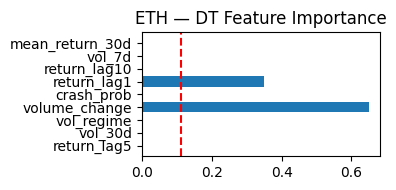


ETH selected features: ['volume_change', 'return_lag1']

ETH — Decision Tree — evaluation summary
Accuracy : 0.544
Precision: 0.486
Recall   : 0.600
F1-score : 0.537

Classification report:
              precision    recall  f1-score   support

           0       0.61      0.50      0.55        38
           1       0.49      0.60      0.54        30

    accuracy                           0.54        68
   macro avg       0.55      0.55      0.54        68
weighted avg       0.56      0.54      0.54        68



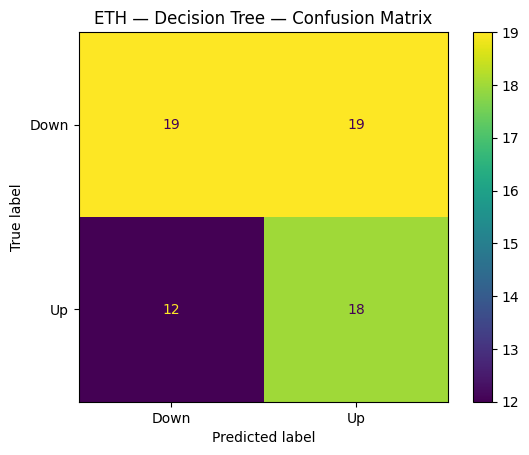

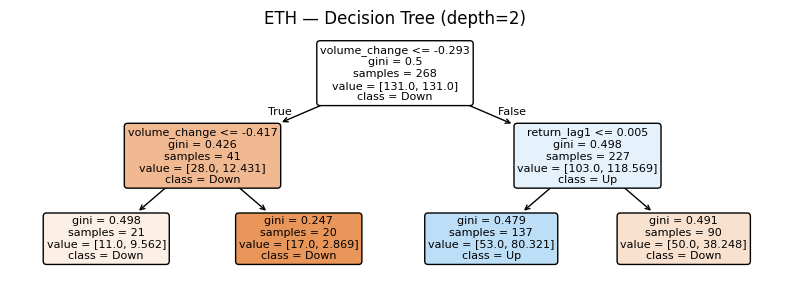


Novo best DT params: {'max_depth': 4, 'min_samples_leaf': 10}


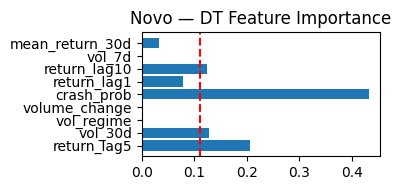


Novo selected features: ['return_lag5', 'vol_30d', 'crash_prob', 'return_lag10']

Novo — Decision Tree — evaluation summary
Accuracy : 0.500
Precision: 0.421
Recall   : 0.421
F1-score : 0.421

Classification report:
              precision    recall  f1-score   support

           0       0.56      0.56      0.56        25
           1       0.42      0.42      0.42        19

    accuracy                           0.50        44
   macro avg       0.49      0.49      0.49        44
weighted avg       0.50      0.50      0.50        44



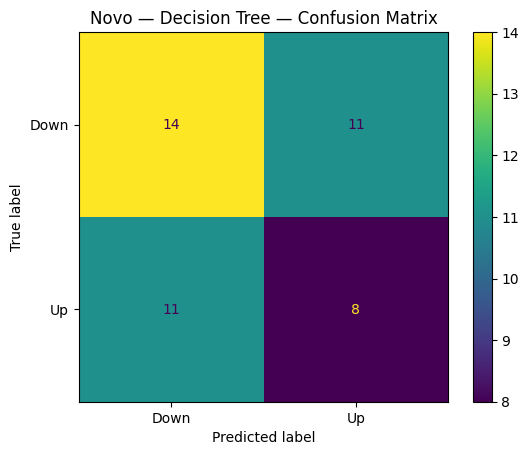

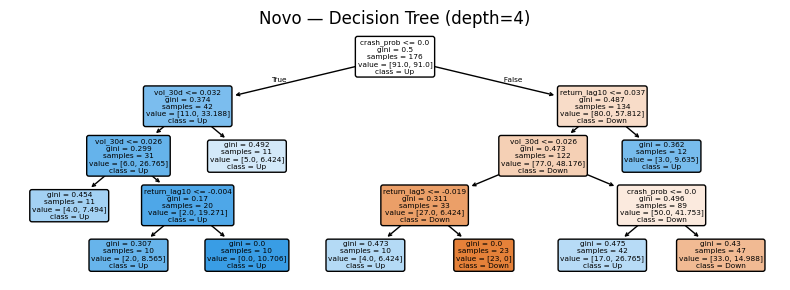

In [29]:
model_eth_dt  = train_evaluate_dt(X_eth,  df_eth["target"],  "ETH")
model_novo_dt = train_evaluate_dt(X_novo, df_novo["target"], "Novo")

### Predicting 5 day ROI direction


ETH best DT params: {'max_depth': 4, 'min_samples_leaf': 20}


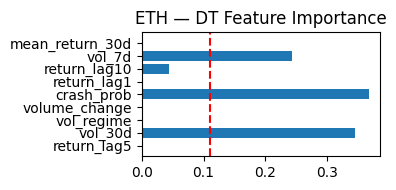


ETH selected features: ['vol_30d', 'crash_prob', 'vol_7d']

ETH — Decision Tree — evaluation summary
Accuracy : 0.412
Precision: 0.233
Recall   : 0.292
F1-score : 0.259

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.48      0.51        44
           1       0.23      0.29      0.26        24

    accuracy                           0.41        68
   macro avg       0.39      0.38      0.39        68
weighted avg       0.44      0.41      0.42        68



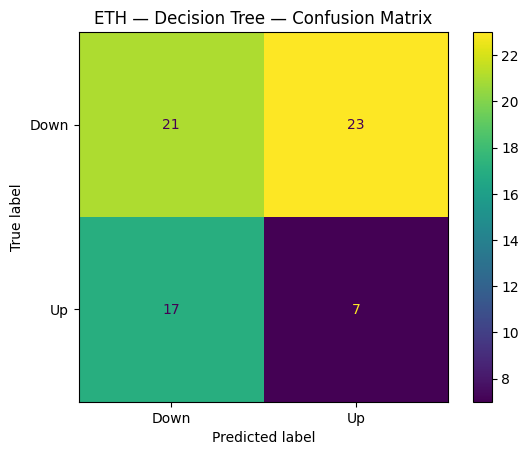

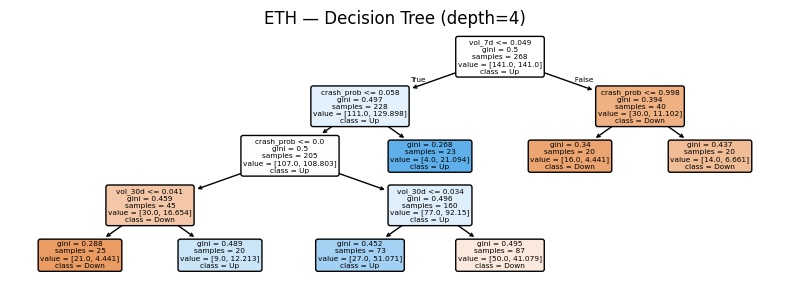


Novo best DT params: {'max_depth': 4, 'min_samples_leaf': 5}


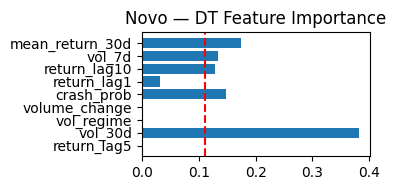


Novo selected features: ['vol_30d', 'crash_prob', 'return_lag10', 'vol_7d', 'mean_return_30d']

Novo — Decision Tree — evaluation summary
Accuracy : 0.500
Precision: 0.444
Recall   : 0.632
F1-score : 0.522

Classification report:
              precision    recall  f1-score   support

           0       0.59      0.40      0.48        25
           1       0.44      0.63      0.52        19

    accuracy                           0.50        44
   macro avg       0.52      0.52      0.50        44
weighted avg       0.53      0.50      0.50        44



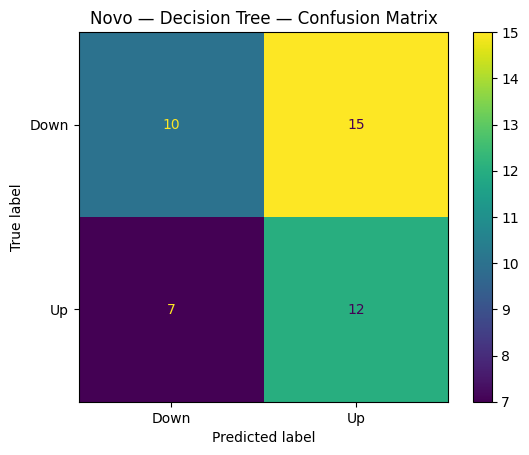

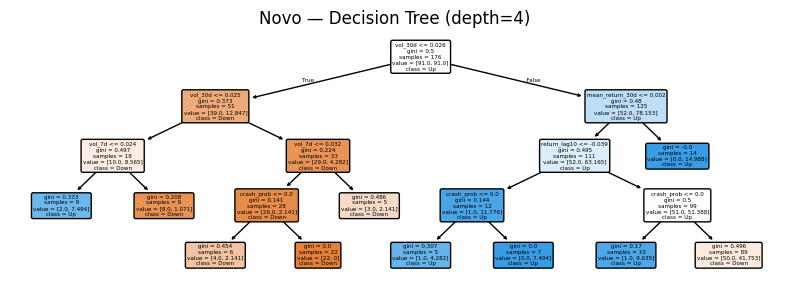

In [30]:
# Target variable: Is Weekly ROI direction positive or negative
# We predict direction only not actual value

df_eth["target"] = (df_eth["Close"].shift(-5) / df_eth["Close"] - 1 > 0).astype(int)   # shift -5 shifts rows upward by 5. So we calculate weekly return as target
df_novo["target"] = (df_novo["Close"].shift(-5) / df_novo["Close"] - 1 > 0).astype(int)                    # If return > 0 returns 1 (true), If return <0 returns 0 (false)
# 1 means positive direction, 0 means negative direction

model_eth_dt  = train_evaluate_dt(X_eth,  df_eth["target"],  "ETH")
model_novo_dt = train_evaluate_dt(X_novo, df_novo["target"], "Novo")

### Predicting 30 day ROI direction


ETH best DT params: {'max_depth': 4, 'min_samples_leaf': 5}


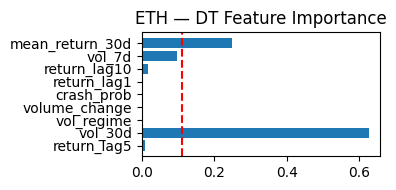


ETH selected features: ['vol_30d', 'mean_return_30d']

ETH — Decision Tree — evaluation summary
Accuracy : 0.441
Precision: 0.073
Recall   : 1.000
F1-score : 0.136

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.42      0.59        65
           1       0.07      1.00      0.14         3

    accuracy                           0.44        68
   macro avg       0.54      0.71      0.36        68
weighted avg       0.96      0.44      0.57        68



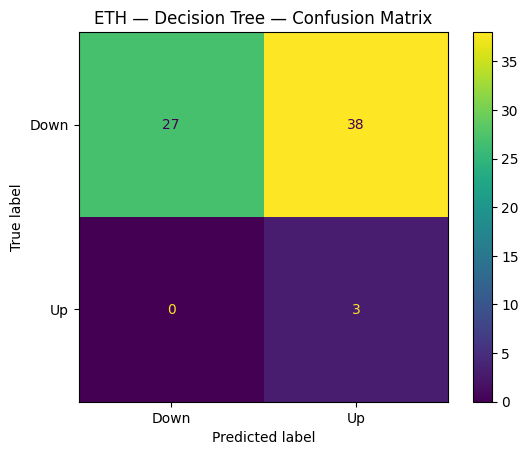

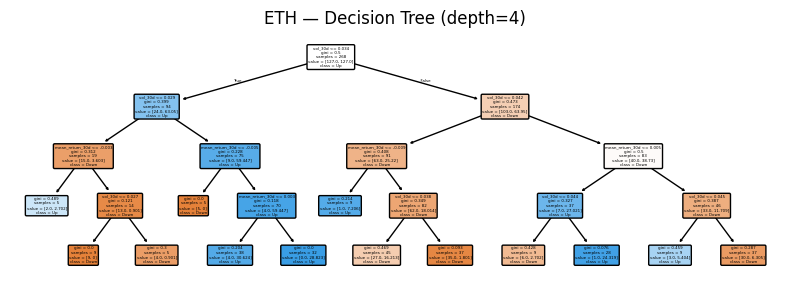


Novo best DT params: {'max_depth': 2, 'min_samples_leaf': 10}


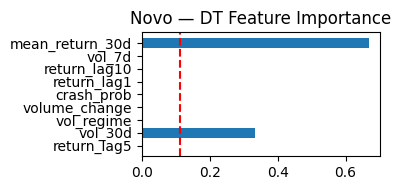


Novo selected features: ['vol_30d', 'mean_return_30d']

Novo — Decision Tree — evaluation summary
Accuracy : 0.091
Precision: 0.000
Recall   : 0.000
F1-score : 0.000

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.09      0.17        44
           1       0.00      0.00      0.00         0

    accuracy                           0.09        44
   macro avg       0.50      0.05      0.08        44
weighted avg       1.00      0.09      0.17        44



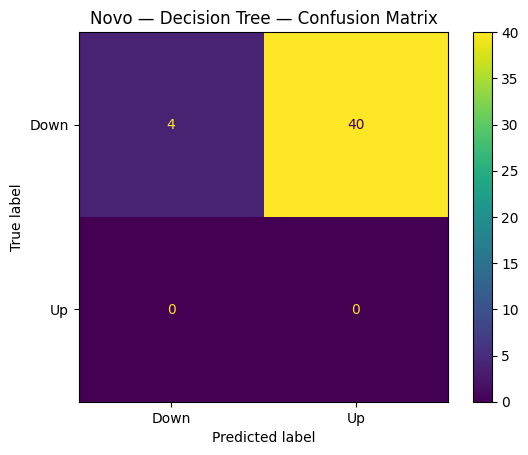

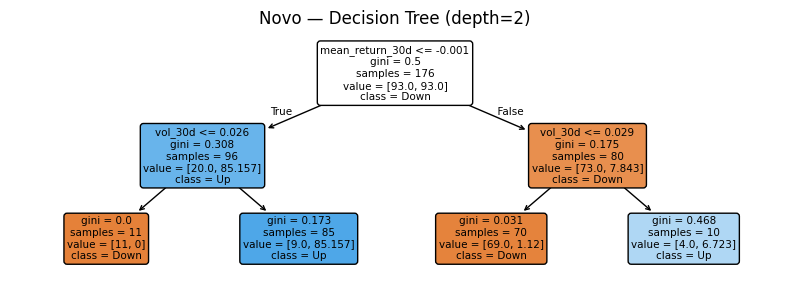

In [31]:
# Target variable: Is Monthly ROI direction positive or negative
# We predict direction only not actual value

df_eth["target"] = (df_eth["Close"].shift(-30) / df_eth["Close"] - 1 > 0).astype(int)   
df_novo["target"] = (df_novo["Close"].shift(-30) / df_novo["Close"] - 1 > 0).astype(int)                    # If return > 0 returns 1 (true), If return <0 returns 0 (false)
# 1 means positive direction, 0 means negative direction

model_eth_dt  = train_evaluate_dt(X_eth,  df_eth["target"],  "ETH")
model_novo_dt = train_evaluate_dt(X_novo, df_novo["target"], "Novo")

### 5.2 XGBoost

In [32]:
# Fitting the model
import xgboost as xgb
from xgboost import XGBClassifier



def train_evaluate_xg(X, y, name):
    # Drop rows with NaN (from rolling windows and shifts)
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # Chronological split (shuffle = false)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Adressing class imbalance (more 0 then 1 y data) -> Improving model accuracy
    counter = Counter(y_train)
    scale = counter[0] / counter[1]
    
    # Getting best parameters for regularization via GridSearchCV
    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {"alpha": [0, 0.1, 0.5, 1], "lambda": [0.5, 1, 2, 5], "learning_rate":[0.01, 0.05, 0.1], "n_estimators":[100, 200, 300]}
    grid = GridSearchCV(XGBClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=42,
        scale_pos_weight=scale),
        param_grid,
        cv = tscv)
    grid.fit(X_train, y_train)
    print(f"\n{name} best regularization params: {grid.best_params_}")
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        reg_alpha=grid.best_params_["alpha"],              # L1 regularization
        reg_lambda=grid.best_params_["lambda"],             # L2 regularization
        random_state=42,
        scale_pos_weight=scale      # reducing class imbalance
    )
    model.fit(X_train, y_train)

    # Optimization measure - Feature selection
    #Plot feature importance
    plt.figure(figsize=(4, 2))
    plt.barh(X.columns, model.feature_importances_)
    plt.axvline(x=model.feature_importances_.mean(), color="red", linestyle="--")
    plt.title(f"{name} — Feature Importance")
    plt.tight_layout()
    plt.show()
    
    # Select features above mean
    selector = SelectFromModel(model, prefit=True, threshold="mean")
    X_train_sel = selector.transform(X_train.values)
    X_test_sel  = selector.transform(X_test.values)
    selected_features = X.columns[selector.get_support()].tolist()
    print(f"\n{name} selected features: {selected_features}")

    # Refit on selected features
    model.fit(X_train_sel, y_train)

    preds = model.predict(X_test_sel)
    evaluate_predictions(y_test, preds, f"{name} — XGBoost")
    return model


### Predicting 1 day ROI direction

In [33]:
# Target variable: Is Daily ROI direction positive or negative
# We predict direction only not actual value

df_eth["target"] = (df_eth["Close"].shift(-1) / df_eth["Close"] - 1 > 0).astype(int)   # shift -1 shifts rows upward by 1. So we calculate 1 day return as target
df_novo["target"] = (df_novo["Close"].shift(-1) / df_novo["Close"] - 1 > 0).astype(int)                    # If return > 0 returns 1 (true), If return <0 returns 0 (false)
# 1 means positive direction, 0 means negative direction


ETH best regularization params: {'alpha': 0.5, 'lambda': 5, 'learning_rate': 0.1, 'n_estimators': 200}


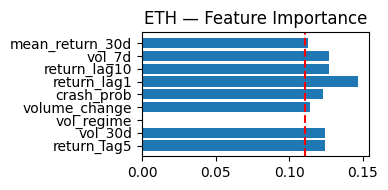


ETH selected features: ['return_lag5', 'vol_30d', 'volume_change', 'crash_prob', 'return_lag1', 'return_lag10', 'vol_7d', 'mean_return_30d']

ETH — XGBoost — evaluation summary
Accuracy : 0.471
Precision: 0.429
Recall   : 0.600
F1-score : 0.500

Classification report:
              precision    recall  f1-score   support

           0       0.54      0.37      0.44        38
           1       0.43      0.60      0.50        30

    accuracy                           0.47        68
   macro avg       0.48      0.48      0.47        68
weighted avg       0.49      0.47      0.47        68



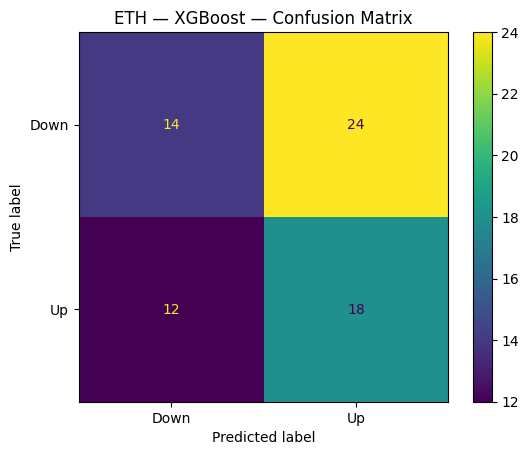


Novo best regularization params: {'alpha': 0.5, 'lambda': 2, 'learning_rate': 0.1, 'n_estimators': 100}


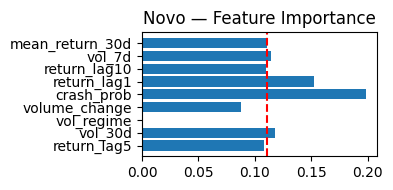


Novo selected features: ['vol_30d', 'crash_prob', 'return_lag1', 'vol_7d']

Novo — XGBoost — evaluation summary
Accuracy : 0.500
Precision: 0.435
Recall   : 0.526
F1-score : 0.476

Classification report:
              precision    recall  f1-score   support

           0       0.57      0.48      0.52        25
           1       0.43      0.53      0.48        19

    accuracy                           0.50        44
   macro avg       0.50      0.50      0.50        44
weighted avg       0.51      0.50      0.50        44



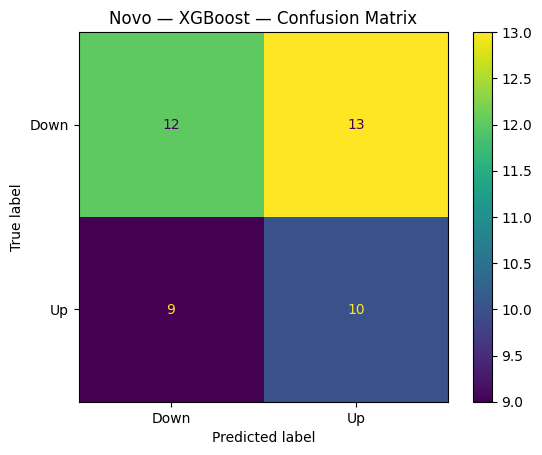

In [34]:
model_eth = train_evaluate_xg(X_eth, df_eth["target"], "ETH")
model_novo = train_evaluate_xg(X_novo, df_novo["target"], "Novo")

### 5 day and 30 day ROI direction using XG boost:

We have decided not to calculate 5 day and 30 day ROI direction using XG boost since accuracy for 1 day ROI direction is already not satisfactory. These values will only worsen as there is an increasing loss of information due to the increasing time window

## Interpretation of Prediction results

---

We have tried to improve model accuracy by: (1) handling class imbalance, (2) determining optimal regularization via GridSearchCV with TimeSeriesSplit, (3) reducing overfitting through systematic feature selection, and (4) expanding the feature set to 9 features including volume and momentum indicators.

Based on the Decision Tree results across all horizons and the XGBoost 1-day results, we chose to limit XGBoost evaluation to the 1-day horizon only. At 5-day and 30-day horizons, the Decision Tree already produced degenerate or near-degenerate models, driven by both assets' sustained downtrends over the observation period. Combined with XGBoost already underperforming at the easier 1-day task, pursuing longer horizons with XGBoost was not considered meaningful.

For the models we can conclude that:

- **1-day ROI direction (Decision Tree):** The Decision Tree is the strongest performer. ETH achieves 54% accuracy with a balanced precision-recall profile, selecting `volume_change` and `return_lag1` as the most informative features. This confirms that short-term momentum carries genuine signal for ETH. Novo achieves 50%, equivalent to random prediction, suggesting no exploitable edge exists for equity with this feature set.

- **1-day ROI direction (XGBoost):** Contrary to expectation, XGBoost underperforms the Decision Tree, achieving 47% for ETH and 50% for Novo. With only 250-300 training observations, XGBoost's added complexity is not justified by the data volume once leakage-free TimeSeriesSplit validation is applied. The simpler Decision Tree wins.

- **5-day and 30-day ROI direction:** Omitted from XGBoost evaluation for two reasons. First, XGBoost already failed to add value at the 1-day horizon, making longer horizons unpromising. Second, Decision Tree results at these horizons were either heavily biased or fully degenerate, reflecting that predictive signal from lagged price and volatility features decays sharply as noise compounds and unobservable external factors dominate.

The sole model providing real value is therefore the **1-day ETH Decision Tree at 54% accuracy**. While modest, this is a meaningful result, as the efficient market hypothesis implies consistent predictability from public price data should not exist. A 54% edge, applied systematically, provides a reasonable basis for the day-trading strategy outlined below.

## 6. Seasonality

# Seasonality analysis

We cannot reasonably make inferences about seasonal or cyclical effects from our data, since we only have one year of observations. Price movements over this period could reflect regular seasonal patterns, but could equally be driven by asset-specific factors such as Novo's company developments or shifting sentiment around cryptocurrency. With a sample size of one year, no statistically meaningful seasonality conclusions can be drawn. Therefore we have decided to conduct a limited intra month seasonality analysis:

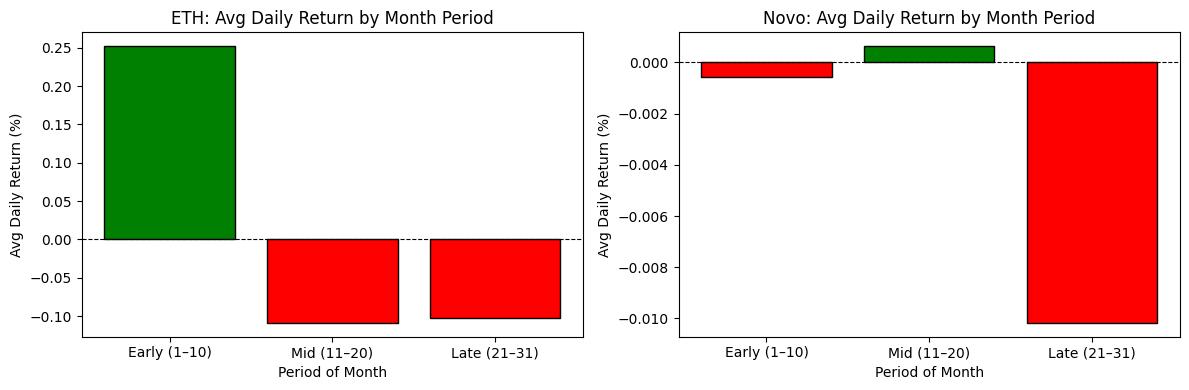

ETH avg return by month period:
 month_period
Early (1–10)    0.252
Mid (11–20)    -0.109
Late (21–31)   -0.102
Name: Change, %, dtype: float64

Novo avg return by month period:
 month_period
Early (1–10)   -0.001
Mid (11–20)     0.001
Late (21–31)   -0.010
Name: daily_return, dtype: float64


In [35]:
# Intra month seasonality

# Extract day-of-month
df_eth["day_of_month"] = df_eth["Date"].dt.day
df_novo["day_of_month"] = df_novo["Date"].dt.day

# Bucket into early / mid / late month
def month_period(day):
    if day <= 10:
        return "Early (1–10)"
    elif day <= 20:
        return "Mid (11–20)"
    else:
        return "Late (21–31)"

df_eth["month_period"] = df_eth["day_of_month"].apply(month_period)
df_novo["month_period"] = df_novo["day_of_month"].apply(month_period)

period_order = ["Early (1–10)", "Mid (11–20)", "Late (21–31)"]

eth_period_avg  = df_eth.groupby("month_period")["Change, %"].mean().reindex(period_order)
novo_period_avg = df_novo.groupby("month_period")["daily_return"].mean().reindex(period_order)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

colors_eth  = ["green" if v >= 0 else "red" for v in eth_period_avg]
colors_novo = ["green" if v >= 0 else "red" for v in novo_period_avg]

axes[0].bar(period_order, eth_period_avg, color=colors_eth, edgecolor="black")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("ETH: Avg Daily Return by Month Period")
axes[0].set_ylabel("Avg Daily Return (%)")
axes[0].set_xlabel("Period of Month")

axes[1].bar(period_order, novo_period_avg, color=colors_novo, edgecolor="black")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Novo: Avg Daily Return by Month Period")
axes[1].set_ylabel("Avg Daily Return (%)")
axes[1].set_xlabel("Period of Month")

plt.tight_layout()
plt.show()

# Summary stats
print("ETH avg return by month period:\n", eth_period_avg.round(3))
print("\nNovo avg return by month period:\n", novo_period_avg.round(3))

## 7. Final discussion

The remaining sections translate the analytical output into an investment-oriented interpretation.  
For a portfolio repository, this is useful because it shows not only technical implementation, but also the ability to connect model output to a business-style recommendation.

# Questions Part

## 1) Should you invest in cryptocurrency (ETH) or equity (Novo Nordisk Stock) ?



**If we had to choose one asset the recommendation is Ethereum**, based on the following evidence from the analysis:

**Descriptive RoI and Volatility**

The dataset covers March 2025 to March 2026. Over this period, ETH delivered a 1-year ROI of -22.7% compared to Novo's -62.9%, a substantial gap even though both assets declined in absolute terms. Daily return volatility was ETH: 0.0409 vs. Novo: 0.0354, meaning ETH is roughly 16% more volatile on a daily basis, but this is  compensated by its significantly better return.

**Market Regime Analysis (KMeans Clustering)**

The 30-day rolling volatility was clustered into two regimes using KMeans:

| Asset | Regime | Mean Return | Std | Days |
|-------|--------|-------------|-----|------|
| ETH | High Volatility | +0.000740 | 0.0478 | 161 |
| ETH | Low Volatility | -0.000367 | 0.0345 | 204 |
| Novo | High Volatility | -0.013799 | 0.0465 | 77 |
| Novo | Low Volatility | +0.001371 | 0.0281 | 172 |

This is a critical distinction. During high-volatility regimes, ETH still generates a positive average daily return (+0.074%), whereas Novo's high-volatility regime coincides with sharply negative returns (-1.38% per day). This means ETH's elevated volatility is harmful instead it leads to higher returns, suggesting a classic risk - return tradeoff. Novo's volatility, by contrast, is disproportionately associated with crash-like episodes.

**Anomaly Detection (Isolation Forest)**

The Isolation Forest with a 5% contamination rate identified extreme events in both assets based on the joint distribution of daily returns and intraday range. Given that Novo's high-volatility regime coincides with strongly negative mean returns, anomaly days in Novo are more likely to represent significant drawdowns. ETH anomalies, while sharp, can occur on both sides of the return distribution, consistent with the more symmetric risk profile observed in the regime statistics above.

**HMM Crash Regime Probability**

The Gaussian HHM identified a crash state as the state with the lowest mean return. For Novo, the high-volatility and high-crash-probability periods are numerous (77 days) and come with mean returns of -1.38%, suggesting that Novo spent significant time in distressed conditions during the observation period. ETH's crash state, while present, is less destructive in expectation, with the high-volatility regime still generating positive average daily returns, suggesting recoveries are more integrated with the elevated volatility.

**Conclusion on Q1:** ETH is the preferred asset. Higher return accompanies only moderately higher volatility, and critically, ETH's high-volatility regime is not a crash regime. Novo's volatility is structurally linked to negative performance, making its risk-return profile inferior over this observation period.

## 2) Capital Allocation Strategy

**Recommendation: ETH short-term 1-day strategy using the Decision Tree model, with split capital.**

**Predictive Model Results**

Three horizons were tested using both Decision Tree and XGBoost classifiers. Based on the Decision Tree results across all horizons and the weak XGBoost 1-day results, XGBoost evaluation was limited to the 1-day horizon only:

| Model | Asset | Horizon | Accuracy | Selected Features |
|-------|-------|---------|----------|-------------------|
| Decision Tree | ETH | 1-day | 54% | volume_change, return_lag1 |
| Decision Tree | Novo | 1-day | 50% | return_lag5, vol_30d, crash_prob, return_lag10 |
| XGBoost | ETH | 1-day | 47% | vol_30d, crash_prob, return_lag1, vol_7d |
| XGBoost | Novo | 1-day | 50% | vol_30d, crash_prob, return_lag1, vol_7d |
| Decision Tree | ETH | 5-day | 41% | Heavily biased toward downward predictions |
| Decision Tree | Novo | 5-day | 50% | Near-degenerate due to sustained downtrend |
| Decision Tree | ETH | 30-day | 44% | Near-degenerate, 3/68 upward predictions |
| Decision Tree | Novo | 30-day | 9% | Fully degenerate, never predicts upward |

Only the 1-day prediction horizon provides actionable signal. The 5-day and 30-day models degrade because both assets trended downward over the sample period, biasing classifiers toward always predicting down, noise compounds with longer horizons, and lagged features carry progressively less explanatory power as the forecast window widens. XGBoost's underperformance relative to the Decision Tree at the 1-day horizon reflects that with only 250-300 training observations, the added model complexity is not justified.

The XGBoost models applied L1/L2 regularization selected via GridSearchCV with TimeSeriesSplit (ETH: alpha=0.5, lambda=5, learning_rate=0.1, n_estimators=200; Novo: alpha=0.5, lambda=2, learning_rate=0.1, n_estimators=100). The most economically meaningful predictors selected across models were crash_prob from the HMM, vol_30d, vol_7d, and return lags — all interpretable signals directly connected to the regime analysis above.

**Allocation Strategy**

The recommended approach is a daily tactical strategy:

- Each day, use the 1-day Decision Tree model to forecast the directional return of ETH. Given no model achieved above-chance accuracy for Novo at any horizon, Novo positions should not be model-driven.
- Allocate capital toward ETH when an upward move is predicted, and avoid or short when a downward move is predicted.
- Never concentrate the full 250,000 DKK in a single directional bet, as the model carries a 46% error rate on any individual trade. Capital should be split into smaller position sizes to limit drawdown from consecutive incorrect predictions.
- The model's value is in aggregate over many trades, not in any single prediction. A 54% edge, applied consistently, is positive in expectation over time.

A pure long-term investment in either asset is not recommended. Over the observation year both assets declined substantially, and our models found no reliable signal beyond the 1-day horizon, making medium or long-term directional bets difficult to justify on the basis of this data.



## 3) Market Timing and Seasonality

We cannot reasonably make inferences about seasonal or cyclical effects from our data, since we only have one year of observations. Price movements over this period could reflect regular seasonal patterns, but could equally be driven by asset-specific factors such as Novo's company developments or shifting sentiment around cryptocurrency. With a sample size of one year, no statistically meaningful intra-year seasonality conclusions can be drawn.
Instead, we analyzed intra-month seasonality as a more tractable question. ETH shows a notable early-month premium, with an average daily return of +0.25% in days 1-10, compared to approximately -0.10% in mid and late-month periods. This could suggest early-month entry points were more favorable for ETH during the observation period. Novo shows no meaningful intra-month variation across any period, which is consistent with equity returns being driven primarily by firm-specific news rather than calendar effects.
These patterns should be interpreted with significant caution. With only approximately 12 observations per bucket for ETH and 8-9 for Novo, none of these differences are likely to be statistically significant and may simply reflect noise inherent to a one-year sample.


## Limitations
- The sample covers roughly one year, which limits any strong seasonality claims.
- Results are sensitive to the chosen observation window and feature construction.
- Predicting return direction is inherently noisy; modest accuracy is normal in financial settings.
- This notebook should be interpreted as an **analytical case study**, not an investable trading strategy.